<a href="https://colab.research.google.com/github/bao2001/group4-gdp/blob/main/notebooks/group4_gdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [144]:
## Phase 1: Quarterly Data Assembly

In [145]:
import pandas as pd
import numpy as np
import yfinance as yf
from pandas_datareader import data as pdr

start = "1990-01-01"
end = "2025-12-31"

# FRED
gdp = pdr.DataReader("GDPC1", "fred", start, end)
unrate = pdr.DataReader("UNRATE", "fred", start, end)
pcepi = pdr.DataReader("PCEPI", "fred", start, end)
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start, end)
spread = pdr.DataReader("T10Y2Y", "fred", start, end)

# Yahoo
sp500 = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False)
vix = yf.download("^VIX", start=start, end=end, auto_adjust=True, progress=False)

# Handle possible multi-index columns from yfinance
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)
if isinstance(vix.columns, pd.MultiIndex):
    vix.columns = vix.columns.get_level_values(0)

sp500 = sp500[["Close"]].rename(columns={"Close": "SP500_Close"})
vix = vix[["Close"]].rename(columns={"Close": "VIX_Close"})

# Resample to quarter end
unrate_q = unrate.resample("QE").mean()
pcepi_q = pcepi.resample("QE").mean()
fedfunds_q = fedfunds.resample("QE").mean()
spread_q = spread.resample("QE").mean()
sp500_q = sp500.resample("QE").last()
vix_q = vix.resample("QE").mean()

# Force GDP to same quarter-end index style
gdp_q = gdp.copy()
gdp_q = gdp_q.to_period("Q").to_timestamp(how="end")
gdp_q.index = gdp_q.index.normalize()

# Normalize all other indexes
for df in [unrate_q, pcepi_q, fedfunds_q, spread_q, sp500_q, vix_q]:
    df.index = df.index.normalize()

# Merge
master = pd.concat(
    [gdp_q, unrate_q, pcepi_q, fedfunds_q, spread_q, sp500_q, vix_q],
    axis=1
)

master.columns = [
    "GDPC1",
    "UNRATE",
    "PCEPI",
    "FEDFUNDS",
    "T10Y2Y",
    "SP500_Close",
    "VIX_Close"
]

print("Before dropna:", master.shape)
print(master.isna().sum())

master = master.dropna().copy()

print("After dropna:", master.shape)
print(master.head())
print(master.tail())

Before dropna: (144, 7)
GDPC1          0
UNRATE         0
PCEPI          0
FEDFUNDS       0
T10Y2Y         0
SP500_Close    0
VIX_Close      0
dtype: int64
After dropna: (144, 7)
                GDPC1    UNRATE      PCEPI  FEDFUNDS    T10Y2Y  SP500_Close  \
1990-03-31  10047.386  5.300000  58.799000  8.250000  0.059032   339.940002   
1990-06-30  10083.855  5.333333  59.333000  8.243333  0.103016   358.019989   
1990-09-30  10090.569  5.700000  60.086667  8.160000  0.602540   306.049988   
1990-12-31   9998.704  6.133333  60.881333  7.743333  0.800161   330.220001   
1991-03-31   9951.916  6.600000  61.202000  6.426667  0.987167   375.220001   

            VIX_Close  
1990-03-31  22.174603  
1990-06-30  18.722063  
1990-09-30  25.195556  
1990-12-31  26.113281  
1991-03-31  22.494754  
                GDPC1    UNRATE       PCEPI  FEDFUNDS    T10Y2Y  SP500_Close  \
2024-12-31  23586.542  4.133333  124.703333  4.650000  0.130000  5881.629883   
2025-03-31  23548.210  4.133333  125.75966

In [146]:
print(master.info())
print(master.isna().sum())
print(master.index.min(), master.index.max())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1990-03-31 to 2025-12-31
Freq: QE-DEC
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GDPC1        144 non-null    float64
 1   UNRATE       144 non-null    float64
 2   PCEPI        144 non-null    float64
 3   FEDFUNDS     144 non-null    float64
 4   T10Y2Y       144 non-null    float64
 5   SP500_Close  144 non-null    float64
 6   VIX_Close    144 non-null    float64
dtypes: float64(7)
memory usage: 9.0 KB
None
GDPC1          0
UNRATE         0
PCEPI          0
FEDFUNDS       0
T10Y2Y         0
SP500_Close    0
VIX_Close      0
dtype: int64
1990-03-31 00:00:00 2025-12-31 00:00:00


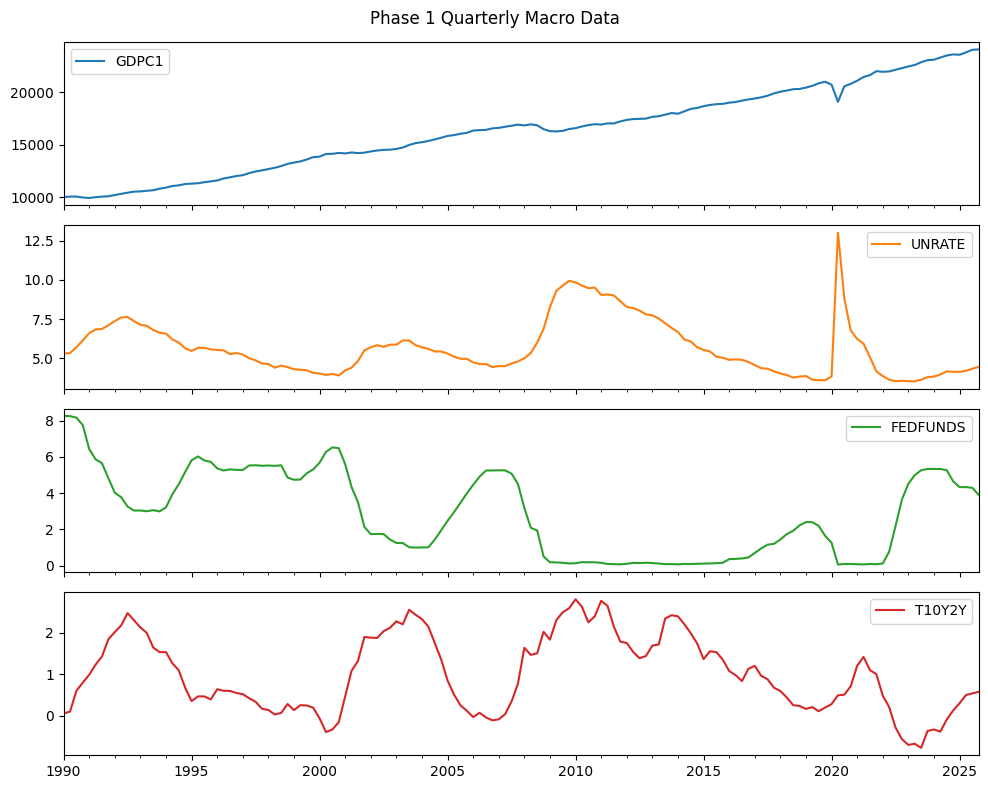

In [147]:
import matplotlib.pyplot as plt

master[["GDPC1", "UNRATE", "FEDFUNDS", "T10Y2Y"]].plot(
    subplots=True, figsize=(10, 8), title="Phase 1 Quarterly Macro Data"
)
plt.tight_layout()
plt.show()

In [148]:
master["gdp_growth"] = master["GDPC1"].pct_change()
master["sp500_return"] = master["SP500_Close"].pct_change()
master["vix_change"] = master["VIX_Close"].pct_change()
master["log_GDPC1"] = np.log(master["GDPC1"])


master.head()

,GDPC1,UNRATE,PCEPI,FEDFUNDS,T10Y2Y,SP500_Close,VIX_Close,gdp_growth,sp500_return,vix_change,log_GDPC1
1990-03-31,10047.386,5.300000,58.799000,8.250000,0.059032,339.940002,22.174603,NaN,NaN,NaN,9.215068
1990-06-30,10083.855,5.333333,59.333000,8.243333,0.103016,358.019989,18.722063,0.003630,0.053186,-0.155698,9.218691
1990-09-30,10090.569,5.700000,60.086667,8.160000,0.602540,306.049988,25.195556,0.000666,-0.145159,0.345768,9.219357
1990-12-31,9998.704,6.133333,60.881333,7.743333,0.800161,330.220001,26.113281,-0.009104,0.078974,0.036424,9.210211
1991-03-31,9951.916,6.600000,61.202000,6.426667,0.987167,375.220001,22.494754,-0.004679,0.136273,-0.138570,9.205520


In [149]:
import os
os.makedirs("/content/data/processed", exist_ok=True)
master.to_csv("/content/data/processed/master_quarterly.csv", index=True)

In [150]:
## Phase 2: GDP Trend-Cycle Decomposition

In [151]:
from statsmodels.tsa.filters.hp_filter import hpfilter
import matplotlib.pyplot as plt

cycle_hp, trend_hp = hpfilter(master["log_GDPC1"], lamb=1600)

master["trend_hp"] = trend_hp
master["cycle_hp"] = cycle_hp

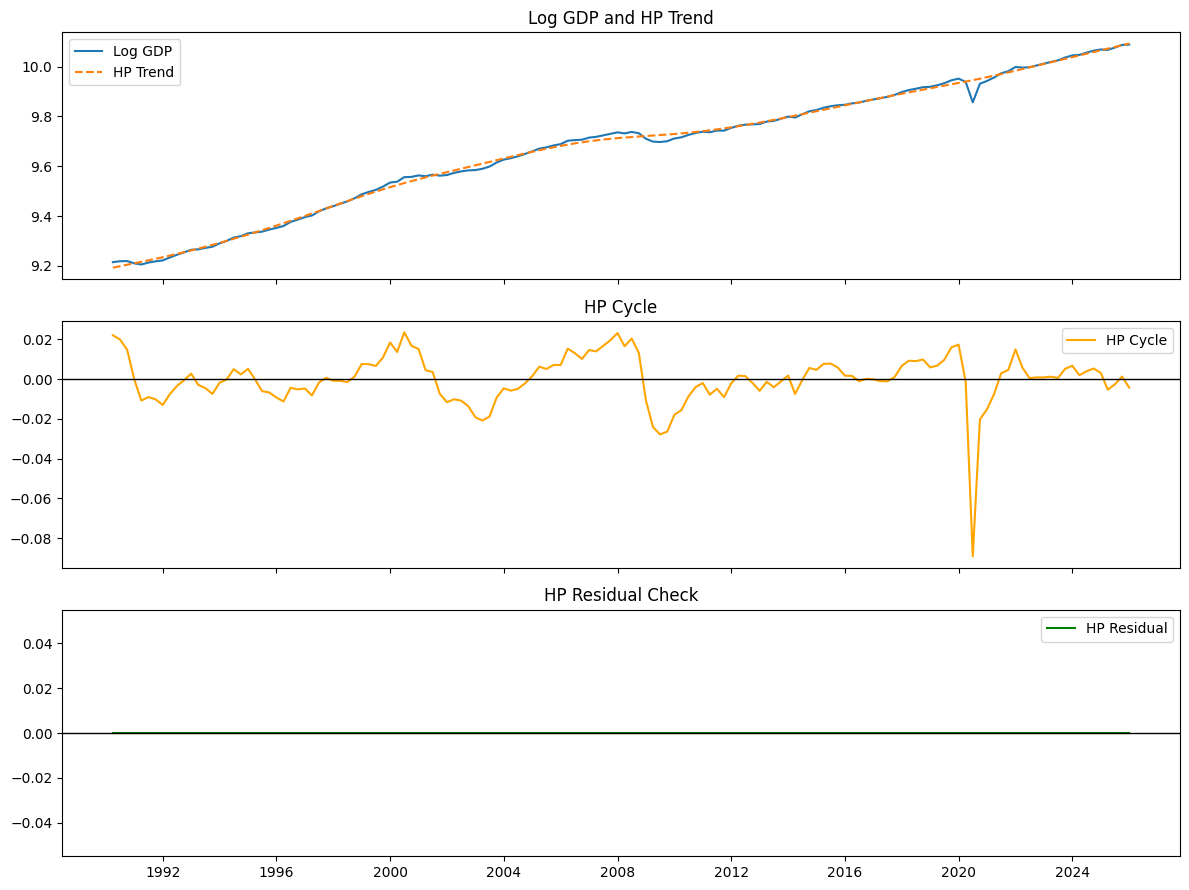

In [152]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(master.index, master["log_GDPC1"], label="Log GDP")
axes[0].plot(master.index, master["trend_hp"], label="HP Trend", linestyle="--")
axes[0].set_title("Log GDP and HP Trend")
axes[0].legend()

axes[1].plot(master.index, master["cycle_hp"], label="HP Cycle", color="orange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("HP Cycle")
axes[1].legend()

axes[2].plot(master.index, master["log_GDPC1"] - master["trend_hp"] - master["cycle_hp"], label="HP Residual", color="green")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("HP Residual Check")
axes[2].legend()

plt.tight_layout()
plt.show()

In [153]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

uc_model = UnobservedComponents(
    master["log_GDPC1"],
    level="local linear trend",
    cycle=True,
    stochastic_cycle=True,
    damped_cycle=True
)

uc_result = uc_model.fit(method="powell", disp=False)
print(uc_result.summary())

                            Unobserved Components Results                            
Dep. Variable:                     log_GDPC1   No. Observations:                  144
Model:                    local linear trend   Log Likelihood                 429.679
                   + damped stochastic cycle   AIC                           -847.357
Date:                       Sun, 26 Apr 2026   BIC                           -829.707
Time:                               18:28:08   HQIC                          -840.185
Sample:                           03-31-1990                                         
                                - 12-31-2025                                         
Covariance Type:                         opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  1.121e-06   5.12e-05      0.022      0

In [154]:
master["trend_uc"] = uc_result.level.smoothed
master["cycle_uc"] = uc_result.cycle.smoothed
master["resid_uc"] = master["log_GDPC1"] - master["trend_uc"] - master["cycle_uc"]

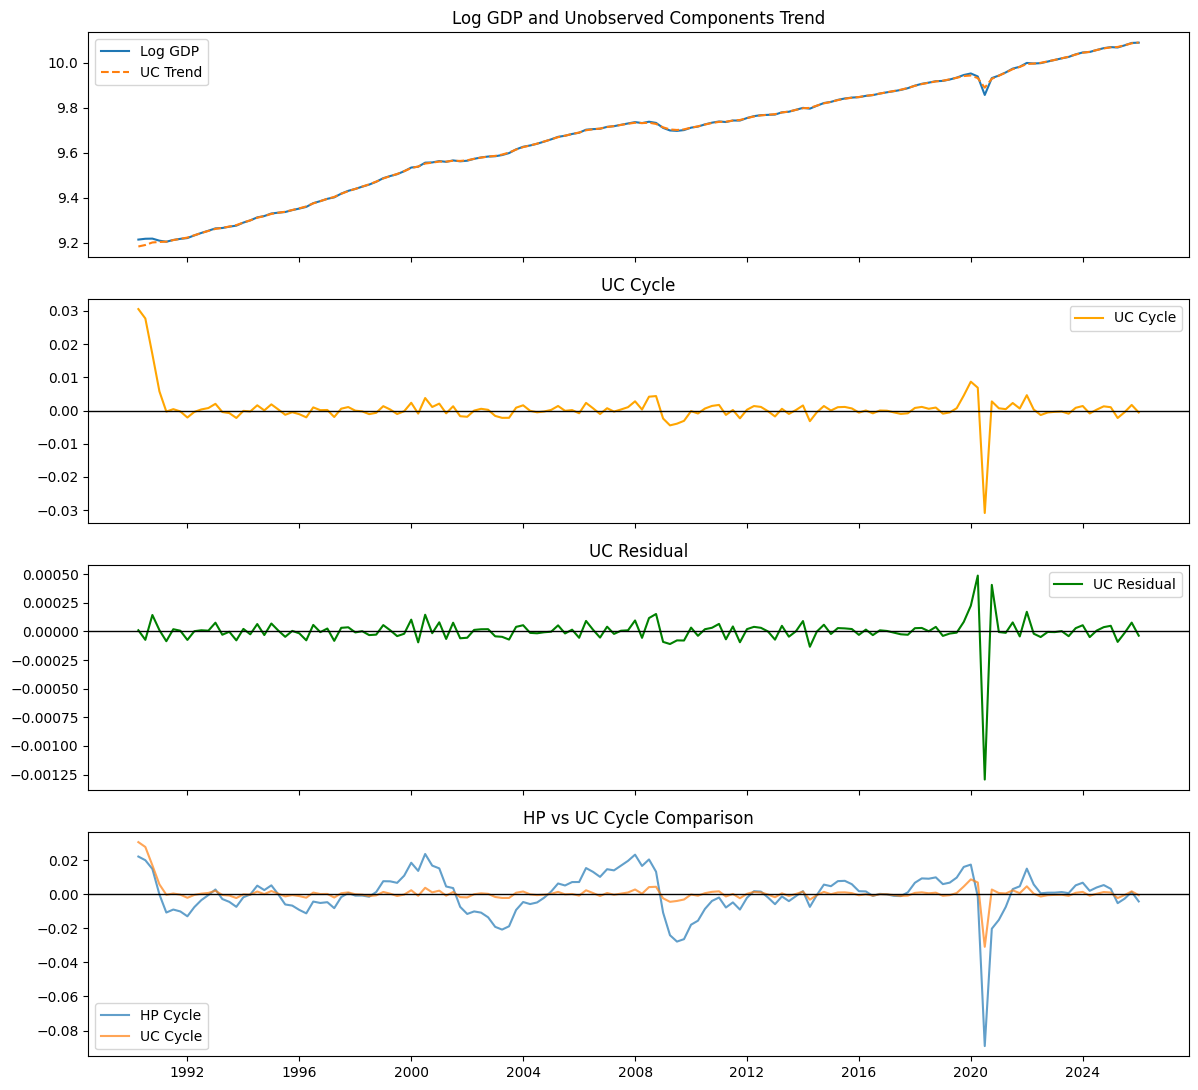

In [155]:
fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

axes[0].plot(master.index, master["log_GDPC1"], label="Log GDP")
axes[0].plot(master.index, master["trend_uc"], label="UC Trend", linestyle="--")
axes[0].set_title("Log GDP and Unobserved Components Trend")
axes[0].legend()

axes[1].plot(master.index, master["cycle_uc"], label="UC Cycle", color="orange")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("UC Cycle")
axes[1].legend()

axes[2].plot(master.index, master["resid_uc"], label="UC Residual", color="green")
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("UC Residual")
axes[2].legend()

axes[3].plot(master.index, master["cycle_hp"], label="HP Cycle", alpha=0.7)
axes[3].plot(master.index, master["cycle_uc"], label="UC Cycle", alpha=0.7)
axes[3].axhline(0, color="black", linewidth=1)
axes[3].set_title("HP vs UC Cycle Comparison")
axes[3].legend()

plt.tight_layout()
plt.show()

In [156]:
## Phase 3: Baseline Forecasting of Next-Quarter Cycle Direction

In [157]:
master["gdp_growth"] = master["GDPC1"].pct_change()
master["pcepi_inflation"] = master["PCEPI"].pct_change()
master["sp500_return"] = master["SP500_Close"].pct_change()
master["vix_change"] = master["VIX_Close"].pct_change()

master["cycle_change"] = master["cycle_uc"].diff()

threshold = master["cycle_change"].std() * 0.10
master["target_next_q"] = (master["cycle_change"].shift(-1) > threshold).astype(int)

base_cols = [
    "UNRATE",
    "PCEPI",
    "FEDFUNDS",
    "T10Y2Y",
    "SP500_Close",
    "VIX_Close",
    "cycle_uc",
    "gdp_growth",
    "pcepi_inflation",
    "sp500_return",
    "vix_change",
    "cycle_change"
]

for col in base_cols:
    master[f"{col}_lag1"] = master[col].shift(1)
    master[f"{col}_lag2"] = master[col].shift(2)

# --- Useful differences / regime indicators ---
master["UNRATE_diff"] = master["UNRATE"].diff()
master["FEDFUNDS_diff"] = master["FEDFUNDS"].diff()
master["T10Y2Y_diff"] = master["T10Y2Y"].diff()
master["yield_curve_inversion"] = (master["T10Y2Y"] < 0).astype(int)
master["yield_curve_inversion_lag1"] = master["yield_curve_inversion"].shift(1)

model_df = master.dropna().copy()

print(model_df.shape)
print(model_df["target_next_q"].value_counts())

(141, 48)
target_next_q
0    82
1    59
Name: count, dtype: int64


In [158]:
master["UNRATE_diff"] = master["UNRATE"].diff()
master["FEDFUNDS_diff"] = master["FEDFUNDS"].diff()
master["T10Y2Y_diff"] = master["T10Y2Y"].diff()
master["VIX_diff"] = master["VIX_Close"].diff()

In [159]:
predictors = [
    "cycle_uc_lag1",
    "cycle_uc_lag2",
    "cycle_change_lag1",
    "cycle_change_lag2",
    "gdp_growth_lag1",
    "gdp_growth_lag2",
    "pcepi_inflation_lag1",
    "UNRATE_diff",
    "FEDFUNDS_diff",
    "T10Y2Y_lag1",
    "yield_curve_inversion_lag1",
    "sp500_return_lag1",
    "vix_change_lag1"
]

X = model_df[predictors]
y = model_df["target_next_q"]

print(X.shape, y.shape)
print(y.value_counts())

(141, 13) (141,)
target_next_q
0    82
1    59
Name: count, dtype: int64


In [160]:
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss

# Predict next quarter direction using current quarter direction
model_df["naive_pred"] = (model_df["cycle_change"] > threshold).astype(int)

naive_eval = model_df.dropna(subset=["naive_pred", "target_next_q"]).copy()

print("Naive Accuracy:", accuracy_score(naive_eval["target_next_q"], naive_eval["naive_pred"]))
print("Naive F1:", f1_score(naive_eval["target_next_q"], naive_eval["naive_pred"]))
print("Naive Brier:", brier_score_loss(naive_eval["target_next_q"], naive_eval["naive_pred"]))

Naive Accuracy: 0.4326241134751773
Naive F1: 0.3220338983050847
Naive Brier: 0.5673758865248227


In [161]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [162]:
preds = []
probs = []
truths = []
dates = []

initial_train_size = 60

for i in range(initial_train_size, len(model_df)):
    train = model_df.iloc[:i]
    test = model_df.iloc[i:i+1]

    X_train = train[predictors]
    y_train = train["target_next_q"]
    X_test = test[predictors]
    y_test = test["target_next_q"]

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=1,
            subsample=1.0,
            random_state=42
        ))
    ])

    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)[0]
    prob = clf.predict_proba(X_test)[0, 1]

    preds.append(pred)
    probs.append(prob)
    truths.append(y_test.iloc[0])
    dates.append(test.index[0])

results = pd.DataFrame({
    "date": dates,
    "y_true": truths,
    "y_pred": preds,
    "y_prob": probs
}).set_index("date")

print("Gradient Boosting Accuracy:", accuracy_score(results["y_true"], results["y_pred"]))
print("Gradient Boosting F1:", f1_score(results["y_true"], results["y_pred"]))
print("Gradient Boosting Brier:", brier_score_loss(results["y_true"], results["y_prob"]))

results.head()

Gradient Boosting Accuracy: 0.5432098765432098
Gradient Boosting F1: 0.4307692307692308
Gradient Boosting Brier: 0.2914584172630541


,y_true,y_pred,y_prob
date,,,
2005-12-31,1,1,0.641163
2006-03-31,0,1,0.500568
2006-06-30,0,0,0.474273
2006-09-30,1,1,0.504922
2006-12-31,0,0,0.185236


In [164]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(results["y_true"], results["y_pred"]))
print(classification_report(results["y_true"], results["y_pred"]))

[[30 15]
 [22 14]]
              precision    recall  f1-score   support

           0       0.58      0.67      0.62        45
           1       0.48      0.39      0.43        36

    accuracy                           0.54        81
   macro avg       0.53      0.53      0.52        81
weighted avg       0.54      0.54      0.54        81



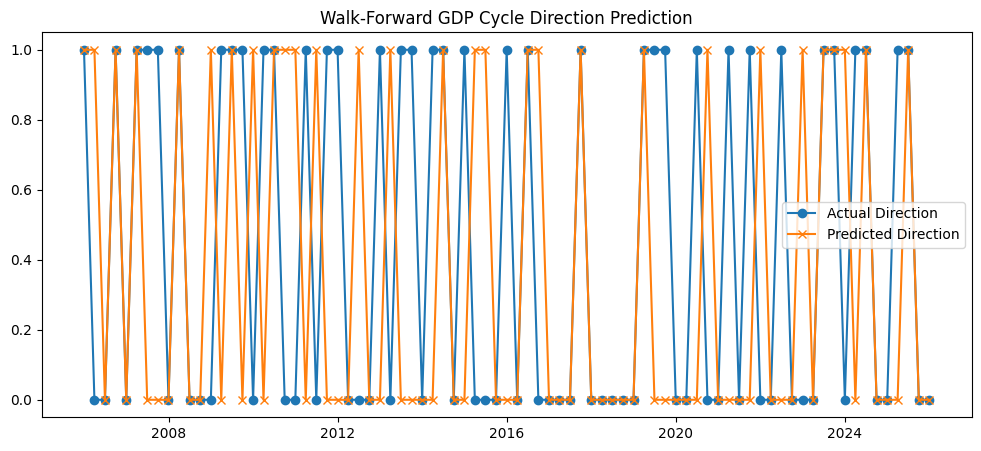

In [165]:
plt.figure(figsize=(12, 5))
plt.plot(results.index, results["y_true"], label="Actual Direction", marker="o")
plt.plot(results.index, results["y_pred"], label="Predicted Direction", marker="x")
plt.title("Walk-Forward GDP Cycle Direction Prediction")
plt.legend()
plt.show()

In [166]:
final_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=1,
        random_state=42
    ))
])

final_clf.fit(X, y)

importances = final_clf.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=predictors).sort_values(ascending=False)

print(feat_imp)

FEDFUNDS_diff                 0.163085
vix_change_lag1               0.161451
UNRATE_diff                   0.161295
cycle_uc_lag1                 0.129721
pcepi_inflation_lag1          0.090866
cycle_uc_lag2                 0.074366
T10Y2Y_lag1                   0.063888
gdp_growth_lag2               0.043922
cycle_change_lag2             0.040446
cycle_change_lag1             0.032876
sp500_return_lag1             0.022112
yield_curve_inversion_lag1    0.010972
gdp_growth_lag1               0.005000
dtype: float64


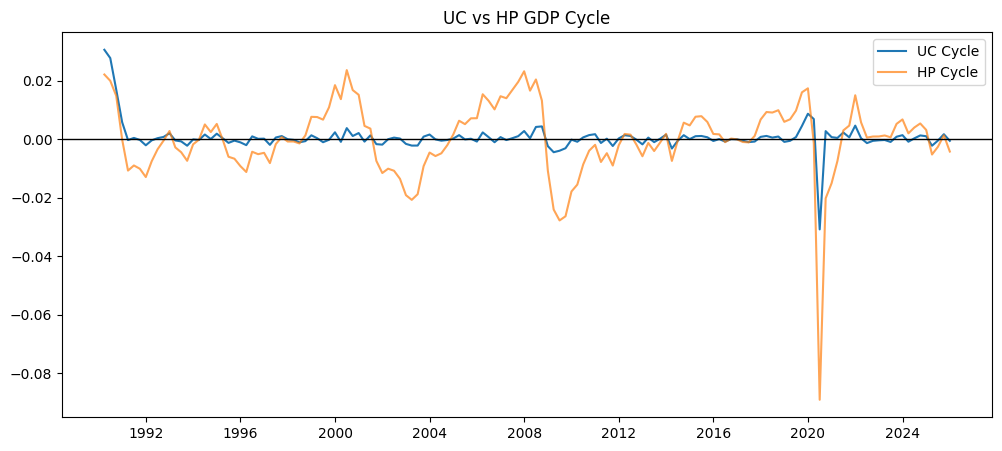

In [167]:
plt.figure(figsize=(12,5))
plt.plot(master.index, master["cycle_uc"], label="UC Cycle")
plt.plot(master.index, master["cycle_hp"], label="HP Cycle", alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title("UC vs HP GDP Cycle")
plt.legend()
plt.show()

In [168]:
import os
os.makedirs("/content/data/processed", exist_ok=True)
master.to_csv("/content/data/processed/master_with_decomposition.csv", index=True)
results.to_csv("/content/data/processed/walkforward_results.csv", index=True)